Number of datasets : 13
Points per dataset : 142
['dino', 'away', 'h_lines', 'v_lines', 'x_shape', 'star', 'high_lines', 'dots', 'circle', 'bullseye', 'slant_up', 'slant_down', 'wide_lines']

Summary statistics for all 13 datasets (rounded to 2 dp):
                n  mean(x)  mean(y)  std(x)  std(y)  r (Pearson)
dataset                                                         
away        142.0    54.27    47.83   16.77   26.94        -0.06
bullseye    142.0    54.27    47.83   16.77   26.94        -0.07
circle      142.0    54.27    47.84   16.76   26.93        -0.07
dino        142.0    54.26    47.83   16.77   26.94        -0.06
dots        142.0    54.26    47.84   16.77   26.93        -0.06
h_lines     142.0    54.26    47.83   16.77   26.94        -0.06
high_lines  142.0    54.27    47.84   16.77   26.94        -0.07
slant_down  142.0    54.27    47.84   16.77   26.94        -0.07
slant_up    142.0    54.27    47.83   16.77   26.94        -0.07
star        142.0    54.27    47.84

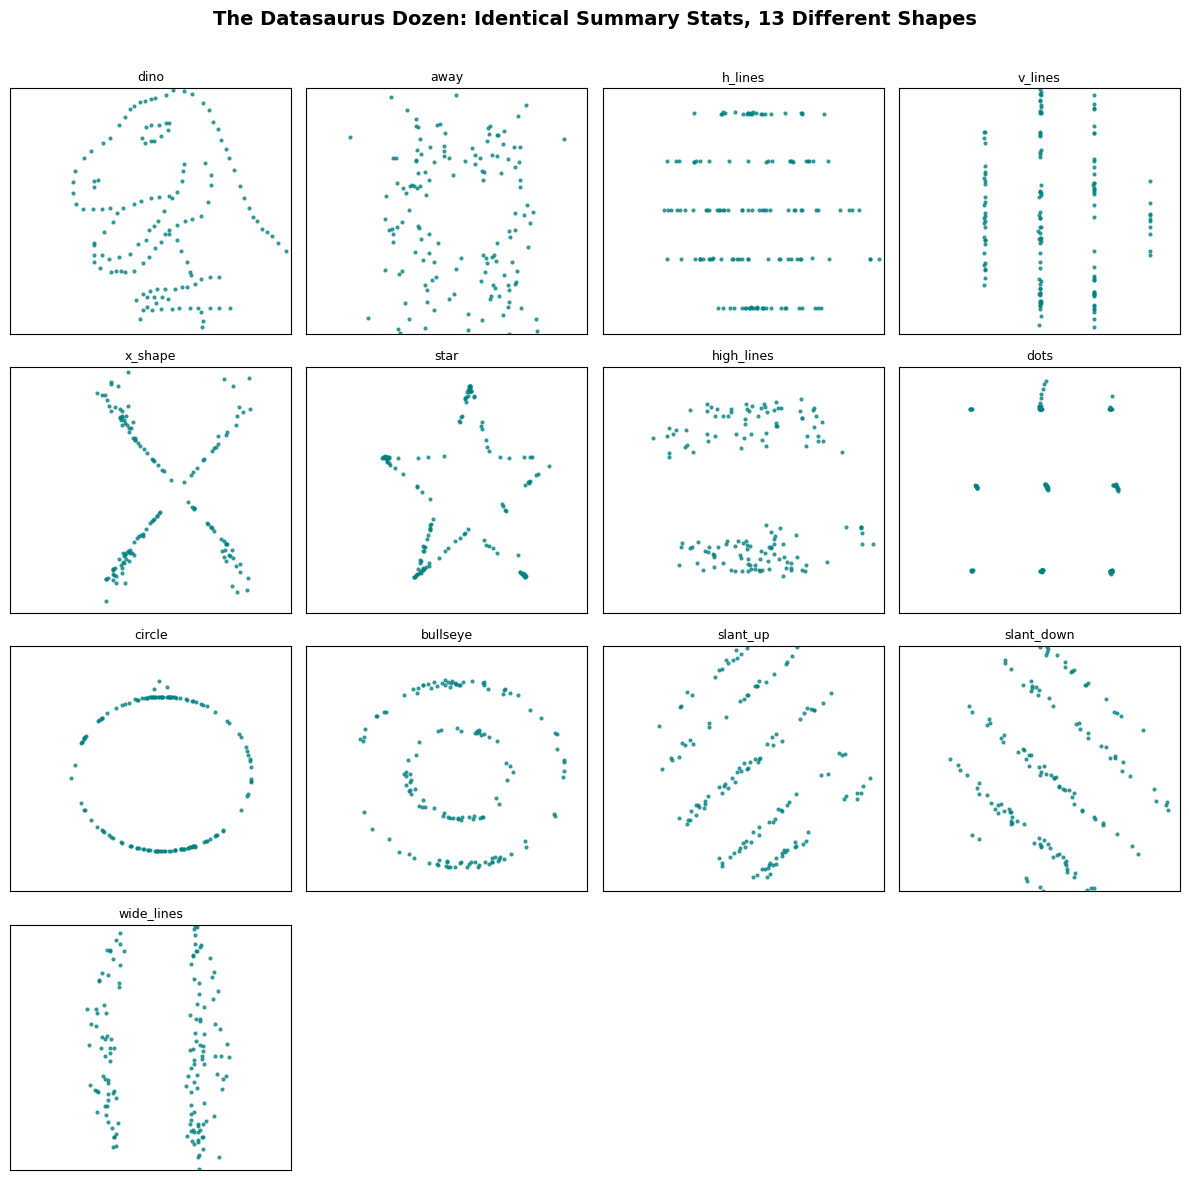


Toy simulated-annealing demo: perturbing 'dino' 20,000 times
BEFORE: mean=(54.263,47.832)  std=(16.765,26.935)
AFTER : mean=(54.265,47.784)  std=(16.770,26.958)
-> stats barely move, but the shape has visibly drifted (see plot).
Saved plot -> datasaurus_perturbation_demo.png


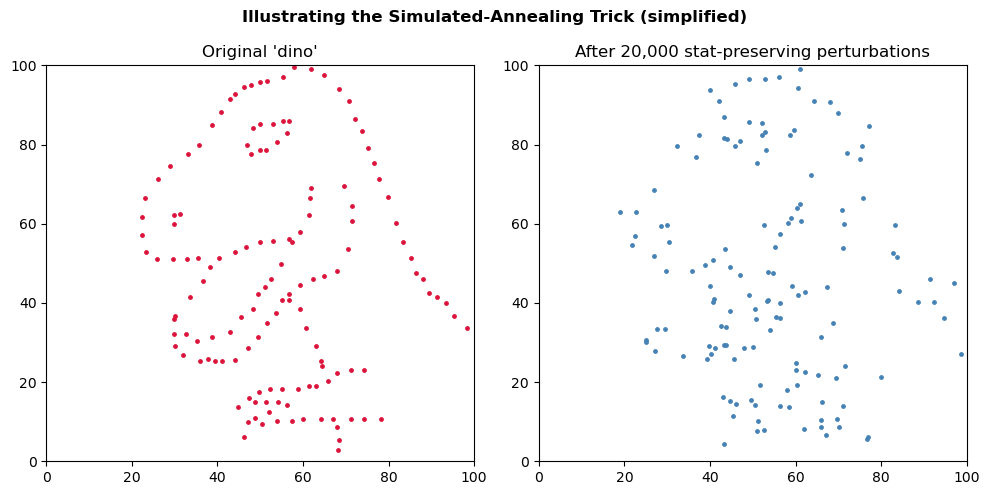

In [1]:
"""
The Datasaurus Dozen - "Same Stats, Different Graphs"
=========================================================
Extends Anscombe's Quartet idea to 13 datasets x 142 points each.
Source data: Matejka & Fitzmaurice (2017), "Same Stats, Different Graphs:
Generating Datasets with Varied Appearance and Identical Statistics through
Simulated Annealing", ACM CHI 2017. Original Datasaurus by Alberto Cairo.
Dataset bundled here as datasaurus_dozen.csv (columns: dataset, x, y).

Run this AFTER / alongside anscombe_quartet.py in the same demo.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Load the 13 datasets (142 points each, n = 1846 rows total)
# ------------------------------------------------------------------
df = pd.read_csv("datasaurus_dozen.csv")
dataset_names = df["dataset"].unique()
print(f"Number of datasets : {len(dataset_names)}")
print(f"Points per dataset : {df.groupby('dataset').size().iloc[0]}")
print(dataset_names.tolist())

# ------------------------------------------------------------------
# 2. Same maths as Anscombe: mean, std (sample), Pearson r --
#    but now across 13 datasets simultaneously
# ------------------------------------------------------------------
summary = df.groupby("dataset").apply(
    lambda g: pd.Series({
        "n": len(g),
        "mean(x)": g["x"].mean(),
        "mean(y)": g["y"].mean(),
        "std(x)": g["x"].std(ddof=1),
        "std(y)": g["y"].std(ddof=1),
        "r (Pearson)": g["x"].corr(g["y"]),
    }),
    include_groups=False,
).round(2)

print("\n" + "=" * 70)
print("Summary statistics for all 13 datasets (rounded to 2 dp):")
print("=" * 70)
print(summary)
print("\n-> mean(x)=54.26, mean(y)=47.83, std(x)=16.76, std(y)=26.93,")
print("   r=-0.06 for EVERY dataset, including the dinosaur.")

# ------------------------------------------------------------------
# 3. Visualise all 13 as a facet grid -- the reveal
# ------------------------------------------------------------------
ncols, nrows = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 12))
for ax, name in zip(axes.flat, dataset_names):
    sub = df[df["dataset"] == name]
    ax.scatter(sub["x"], sub["y"], s=4, alpha=0.7, color="teal")
    ax.set_title(name, fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(dataset_names):]:
    ax.axis("off")

fig.suptitle("The Datasaurus Dozen: Identical Summary Stats, 13 Different Shapes",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("datasaurus_dozen.png", dpi=150)
print("\nSaved plot -> datasaurus_dozen.png")
plt.show()

# ------------------------------------------------------------------
# 4. BONUS -- toy simulated annealing (illustrative, simplified)
#
#    The real Matejka & Fitzmaurice algorithm repeatedly:
#      a. picks a random point, nudges it by a small random step
#      b. checks it still lies close enough to a target SHAPE
#         (e.g. within a fixed distance of the dinosaur outline)
#      c. computes the new mean/std/corr and accepts the move only if
#         they stay within a fixed tolerance (e.g. +-0.001) of the
#         ORIGINAL statistics
#      d. uses a simulated-annealing "temperature" so early on it
#         accepts bigger, more random moves, and later only accepts
#         moves that keep drifting toward the target shape
#
#    Below is a SIMPLIFIED version (no shape constraint) that shows
#    the core statistical trick: perturb points randomly, but only
#    keep a move if mean & std stay within tolerance of the original.
#    Watch how the point cloud can still wander/reshape while the
#    numbers barely move.
# ------------------------------------------------------------------
rng = np.random.default_rng(42)

def perturb_preserving_stats(x, y, n_iter=20000, step=0.3, tol=0.05):
    x, y = x.copy(), y.copy()
    target_mean_x, target_mean_y = x.mean(), y.mean()
    target_std_x, target_std_y = x.std(ddof=1), y.std(ddof=1)

    for _ in range(n_iter):
        i = rng.integers(0, len(x))
        dx, dy = rng.normal(0, step, size=2)
        x_new, y_new = x.copy(), y.copy()
        x_new[i] += dx
        y_new[i] += dy

        # Accept only if summary stats stay within tolerance of target
        ok = (
            abs(x_new.mean() - target_mean_x) < tol
            and abs(y_new.mean() - target_mean_y) < tol
            and abs(x_new.std(ddof=1) - target_std_x) < tol
            and abs(y_new.std(ddof=1) - target_std_y) < tol
        )
        if ok:
            x, y = x_new, y_new
    return x, y

dino = df[df["dataset"] == "dino"]
x0, y0 = dino["x"].to_numpy(), dino["y"].to_numpy()
x1, y1 = perturb_preserving_stats(x0, y0)

print("\n" + "=" * 70)
print("Toy simulated-annealing demo: perturbing 'dino' 20,000 times")
print("=" * 70)
print(f"BEFORE: mean=({x0.mean():.3f},{y0.mean():.3f})  std=({x0.std(ddof=1):.3f},{y0.std(ddof=1):.3f})")
print(f"AFTER : mean=({x1.mean():.3f},{y1.mean():.3f})  std=({x1.std(ddof=1):.3f},{y1.std(ddof=1):.3f})")
print("-> stats barely move, but the shape has visibly drifted (see plot).")

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.scatter(x0, y0, s=6, color="crimson")
ax1.set_title("Original 'dino'")
ax1.set_xlim(0, 100); ax1.set_ylim(0, 100)
ax2.scatter(x1, y1, s=6, color="steelblue")
ax2.set_title("After 20,000 stat-preserving perturbations")
ax2.set_xlim(0, 100); ax2.set_ylim(0, 100)
fig2.suptitle("Illustrating the Simulated-Annealing Trick (simplified)", fontweight="bold")
plt.tight_layout()
plt.savefig("datasaurus_perturbation_demo.png", dpi=150)
print("Saved plot -> datasaurus_perturbation_demo.png")
plt.show()